C:\Users\gnguy\AppData\Local\Temp\ipykernel_22572\3240951139.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


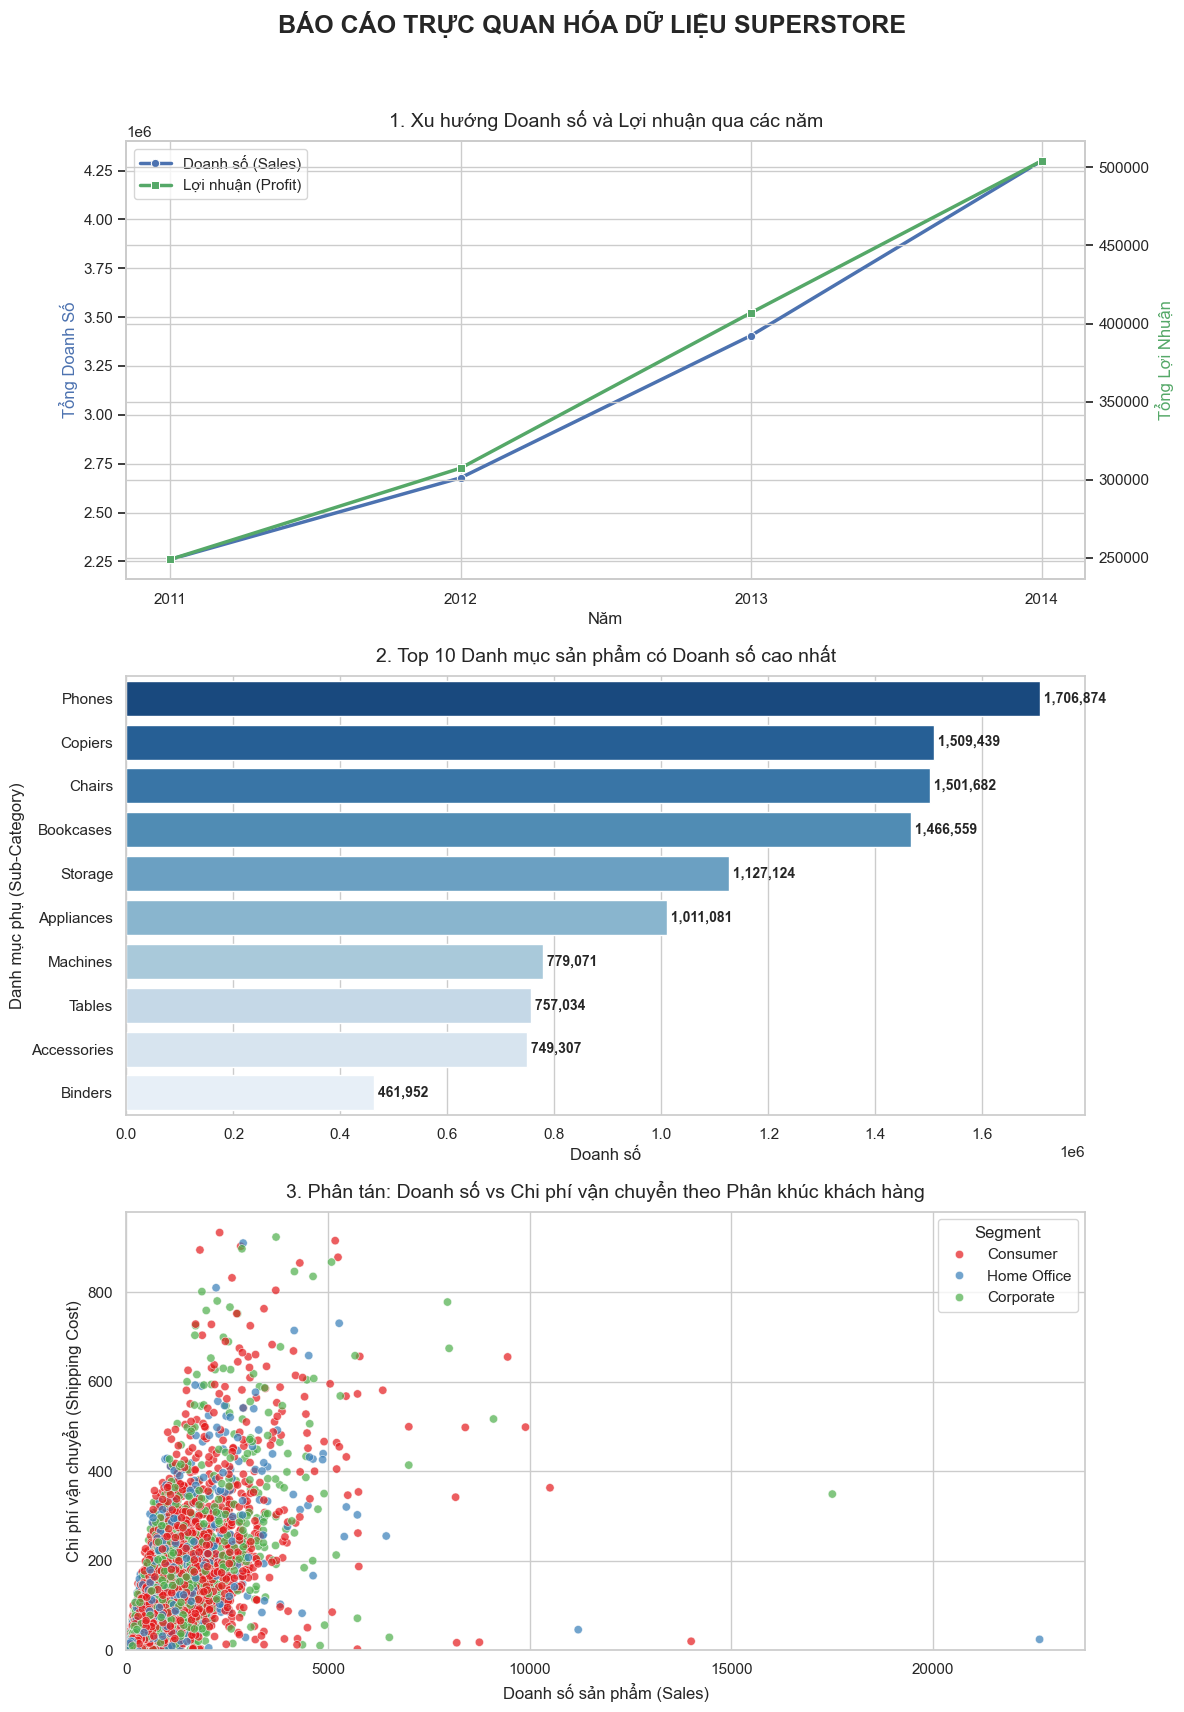

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Đọc dữ liệu từ file CSV
# Sử dụng encoding='utf-8' hoặc 'latin1'/'ansi' tùy thuộc vào định dạng file nguồn
try:
    df = pd.read_csv("DATN---Phantom-Data/Dataset/superstore.csv", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(
        "DATN---Phantom-Data/Dataset/superstore.csv", encoding="latin1"
    )  # Dự phòng nếu lỗi font

# Chuẩn hóa lại tên một số cột chính cho dễ gọi code nếu cần
# Ở đây ta tập trung vào các cột chuẩn tiếng Anh: 'Sales', 'Profit', 'Year', 'Sub.Category', 'Segment', 'Shipping.Cost'

# Cấu hình giao diện biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

# Thiết lập vùng vẽ gồm 3 biểu đồ khác nhau
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle(
    "BÁO CÁO TRỰC QUAN HÓA DỮ LIỆU SUPERSTORE",
    fontsize=18,
    fontweight="bold",
    y=0.95,
)

# ------------------------------------------------------------------
# BIỂU ĐỒ 1: Xu hướng Doanh số & Lợi nhuận theo Năm (Trend Line)
# ------------------------------------------------------------------
yearly_data = df.groupby("Year")[["Sales", "Profit"]].sum().reset_index()

ax1 = axes[0]
ax1_twin = ax1.twinx()  # Tạo trục tung thứ 2 vì lệch quy mô dữ liệu

# Vẽ đường Sales (Trục bên trái)
sns.lineplot(
    data=yearly_data,
    x="Year",
    y="Sales",
    marker="o",
    color="b",
    linewidth=2.5,
    ax=ax1,
    label="Doanh số (Sales)",
)
# Vẽ đường Profit (Trục bên phải)
sns.lineplot(
    data=yearly_data,
    x="Year",
    y="Profit",
    marker="s",
    color="g",
    linewidth=2.5,
    ax=ax1_twin,
    label="Lợi nhuận (Profit)",
)

ax1.set_title("1. Xu hướng Doanh số và Lợi nhuận qua các năm", fontsize=14, pad=10)
ax1.set_xlabel("Năm", fontsize=12)
ax1.set_ylabel("Tổng Doanh Số", color="b", fontsize=12)
ax1_twin.set_ylabel("Tổng Lợi Nhuận", color="g", fontsize=12)
ax1.set_xticks(yearly_data["Year"])

# Phối hợp legend của cả 2 trục
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
ax1_twin.get_legend().remove()


# ------------------------------------------------------------------
# BIỂU ĐỒ 2: Top 10 Danh mục phụ có Doanh số cao nhất (Bar Chart)
# ------------------------------------------------------------------
sub_cat_sales = (
    df.groupby("Sub.Category")["Sales"]
    .sum()
    .reset_index()
    .sort_values(by="Sales", ascending=False)
    .head(10)
)

ax2 = axes[1]
sns.barplot(
    data=sub_cat_sales, x="Sales", y="Sub.Category", palette="Blues_r", ax=ax2
)

ax2.set_title("2. Top 10 Danh mục sản phẩm có Doanh số cao nhất", fontsize=14, pad=10)
ax2.set_xlabel("Doanh số", fontsize=12)
ax2.set_ylabel("Danh mục phụ (Sub-Category)", fontsize=12)

# Thêm giá trị số vào đầu mỗi cột
for index, value in enumerate(sub_cat_sales["Sales"]):
    ax2.text(value, index, f" {value:,.0f}", va="center", fontsize=10, weight="bold")


# ------------------------------------------------------------------
# BIỂU ĐỒ 3: Mối quan hệ giữa Chi phí vận chuyển & Doanh số (Scatter Plot)
# ------------------------------------------------------------------
ax3 = axes[2]
sns.scatterplot(
    data=df,
    x="Sales",
    y="Shipping.Cost",
    hue="Segment",
    alpha=0.7,
    palette="Set1",
    ax=ax3,
)

ax3.set_title(
    "3. Phân tán: Doanh số vs Chi phí vận chuyển theo Phân khúc khách hàng",
    fontsize=14,
    pad=10,
)
ax3.set_xlabel("Doanh số sản phẩm (Sales)", fontsize=12)
ax3.set_ylabel("Chi phí vận chuyển (Shipping Cost)", fontsize=12)
ax3.set_xlim(left=0)  # Giới hạn để biểu đồ tập trung vùng dữ liệu chính
ax3.set_ylim(bottom=0)

# Tối ưu khoảng cách giữa các biểu đồ con và hiển thị
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()